# CAA Model Replication - Group Data
Replicating results from Kang et al. using Table C3 DISP parameters.

Note: Default repository data contains 7,735 trials (filtered) vs 
9,876 trials in published results. This accounts for small differences 
in NLL (813.04 vs 804.75), AIC (1650 vs 1586) and BIC (1734 vs 1590).

In [1]:
from caa_model import dual_process as dp
from caa_model.dual_process import compute_model_gof
from caa_model.dual_process import predicted_proportions_sim as pps
from caa_model.dual_process import predicted_proportions as pp
from caa_model.newModel import predicted_proportions
from caa_model.dual_process import INF_PROXY, EPS, DELTA_T, MAX_T, NR_TSTEPS, NR_SSTEPS

C:\Users\mbh32\AppData\Local\Programs\Python\Python312\Lib\shelve.py:114: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  value = Unpickler(f).load()


In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import yaml
import pandas as pd

In [3]:
data = dp.DATA
c_high = [0.998, 0.0]
c = 0.998
mu_r = 0.002
mu_f = 0.306
d_r = 0.004
d_f = 0.374
tc_bound = 0.059
r_bound = 0.001
x0 = -0.131
mu_r0 = -0.014
mu_f0 = -0.244
deltaT = 0.586
t_offset = 0.513

# Replicating Figure 8 using MC Sims

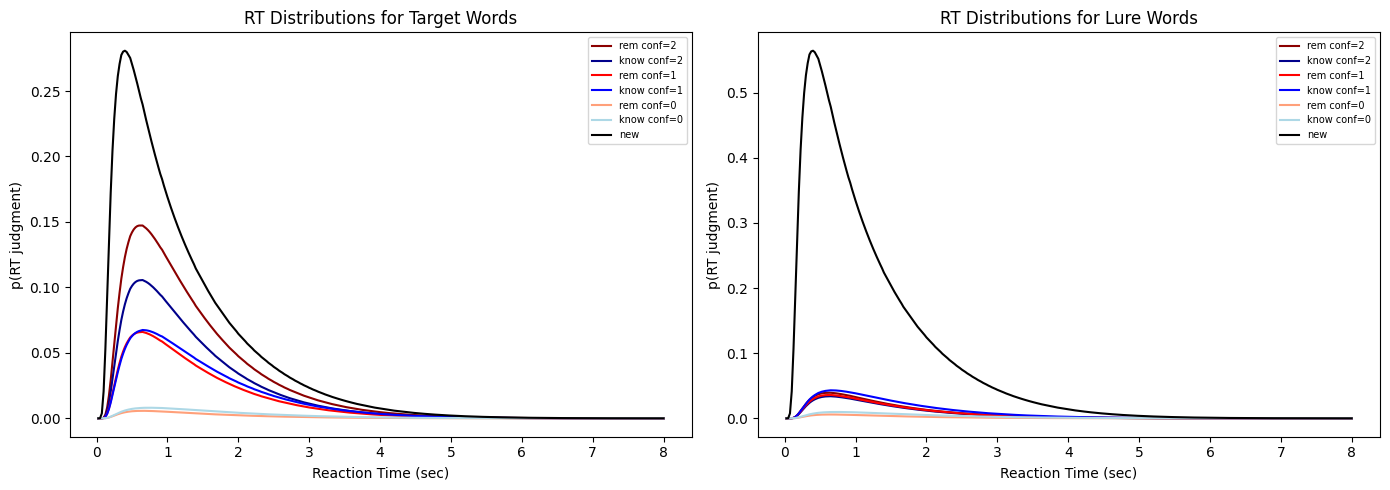

In [4]:
p_rem, p_know, p_new, t = pp(c_high, mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, deltaT)
p_rem_lures, p_know_lures, p_new_lures, t = pp(c_high, mu_r0, mu_f0, d_r, d_f, tc_bound, r_bound, x0, deltaT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ['conf=2', 'conf=1', 'conf=0']
colors_rem  = ['darkred', 'red', 'lightsalmon']
colors_know = ['darkblue', 'blue', 'lightblue']

for i in range(3):
    axes[0].plot(t, p_rem[i]  / DELTA_T, color=colors_rem[i],  label=f'rem {confidence_labels[i]}')
    axes[0].plot(t, p_know[i] / DELTA_T, color=colors_know[i], label=f'know {confidence_labels[i]}')
axes[0].plot(t, p_new / DELTA_T, color='black', label='new')
axes[0].set_title('RT Distributions for Target Words')
axes[0].set_xlabel('Reaction Time (sec)')
axes[0].set_ylabel('p(RT judgment)')
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i]  / DELTA_T, color=colors_rem[i],  label=f'rem {confidence_labels[i]}')
    axes[1].plot(t, p_know_lures[i] / DELTA_T, color=colors_know[i], label=f'know {confidence_labels[i]}')
axes[1].plot(t, p_new_lures / DELTA_T, color='black', label='new')
axes[1].set_title('RT Distributions for Lure Words')
axes[1].set_xlabel('Reaction Time (sec)')
axes[1].set_ylabel('p(RT judgment)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

# Using Predicted_Proportions

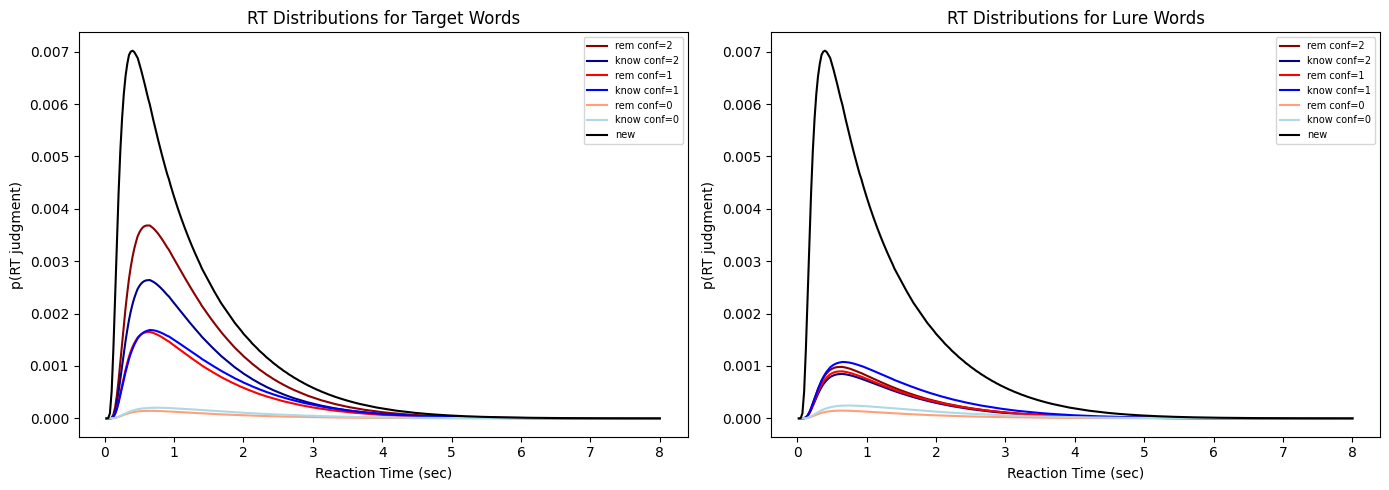

In [5]:
p_rem, p_know, p_new, t = pp(c_high, mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, deltaT)

p_rem_lures, p_know_lures, p_new_lures, t = pp(c_high, mu_r0, mu_f0, d_r, d_f, tc_bound, r_bound, x0, deltaT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

confidence_labels = ['conf=2', 'conf=1', 'conf=0']
colors_rem = ['darkred', 'red', 'lightsalmon']
colors_know = ['darkblue', 'blue', 'lightblue']

for i in range(3):
    axes[0].plot(t, p_rem[i], color=colors_rem[i], label = f'rem {confidence_labels[i]}')
    axes[0].plot(t, p_know[i], color=colors_know[i], label=f'know {confidence_labels[i]}')
axes[0].plot(t, p_new, color='black', label='new')
axes[0].set_title('RT Distributions for Target Words')
axes[0].set_xlabel('Reaction Time (sec)')
axes[0].set_ylabel('p(RT judgment)')
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_lures[i], color=colors_rem[i], label = f'rem {confidence_labels[i]}')
    axes[1].plot(t, p_know_lures[i], color=colors_know[i], label=f'know {confidence_labels[i]}')
axes[1].plot(t, p_new, color='black', label='new')
axes[1].set_title('RT Distributions for Lure Words')
axes[1].set_xlabel('Reaction Time (sec)')
axes[1].set_ylabel('p(RT judgment)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


# Figure 8B Replication

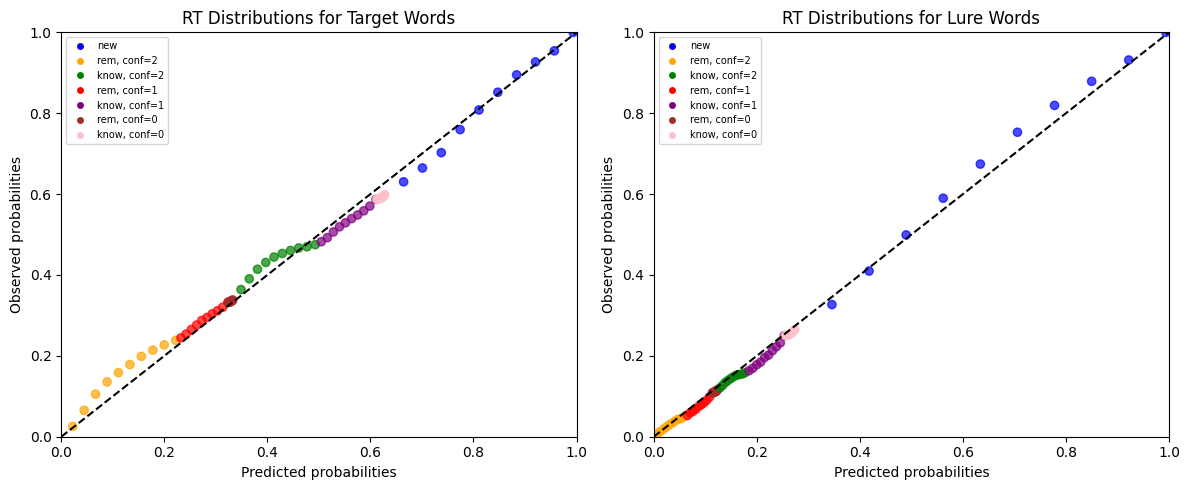

In [6]:
c = 0.998

params_est_old = [[c, 0], mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, deltaT, t_offset]
params_est_new = [[c, 0], mu_r0, mu_f0, d_r, d_f, tc_bound, r_bound, x0, deltaT, t_offset]


p_obs_old, p_pred_old = dp.compute_model_prop(params_est_old, data.rem_hit.rt, data.know_hit.rt, data.miss.rt,data.rem_hit.conf,data.know_hit.conf)

p_obs_new, p_pred_new = dp.compute_model_prop(params_est_new,data.rem_fa.rt,data.know_fa.rt,data.CR.rt,data.rem_fa.conf,data.know_fa.conf)

p_obs_cum_old = np.cumsum(p_obs_old)
p_pred_cum_old = np.cumsum(p_pred_old)
p_obs_cum_new = np.cumsum(p_obs_new)
p_pred_cum_new = np.cumsum(p_pred_new)

segment_colors = (
    ['orange']*10 +
    ['red']*10 +
    ['brown']*10 +
    ['green']*10 +
    ['purple']*10 +
    ['pink']*10 +
    ['blue']*10
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, p_obs_cum, p_pred_cum, title in zip(
    axes,
    [p_obs_cum_old, p_obs_cum_new],
    [p_pred_cum_old, p_pred_cum_new],
    ['RT Distributions for Target Words', 'RT Distributions for Lure Words']
):
    ax.scatter(p_pred_cum, p_obs_cum, c=segment_colors, alpha=0.7)
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xlabel('Predicted probabilities')
    ax.set_ylabel('Observed probabilities')
    ax.set_title(title)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0],marker='o',color='w',markerfacecolor='blue',label='new'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='orange',label='rem, conf=2'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='green',label='know, conf=2'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='red',label='rem, conf=1'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='purple',label='know, conf=1'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='brown',label='rem, conf=0'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='pink',label='know, conf=0'),
]
axes[0].legend(handles=legend_elements, fontsize=7)
axes[1].legend(handles=legend_elements, fontsize=7)

plt.tight_layout()
plt.show()


plt.show()

# Replicating Table 6 

In [7]:
data = dp.DATA

model_params = [c, mu_r, mu_f, d_r, d_f, tc_bound, r_bound, x0, mu_r0, mu_f0, deltaT, t_offset]

neg_log_lik = dp.compute_gof_all(model_params, use_chisq=False)
n_params = 12
n_data = len(data.rem_hit.rt) + len(data.know_hit.rt) + \
          len(data.CR.rt) + len(data.miss.rt) + \
          len(data.rem_fa.rt) + len(data.know_fa.rt)

print(f"N data points: {n_data}")

AIC = 2*n_params + 2*neg_log_lik
BIC = n_params * np.log(n_data) + 2*neg_log_lik

print(f"Negative log likelihood: {neg_log_lik:.2f}")
print(f"AIC: {AIC:.0f}")
print(f"BIC: {BIC:.0f}")

N data points: 7735
Negative log likelihood: 813.04
AIC: 1650
BIC: 1734


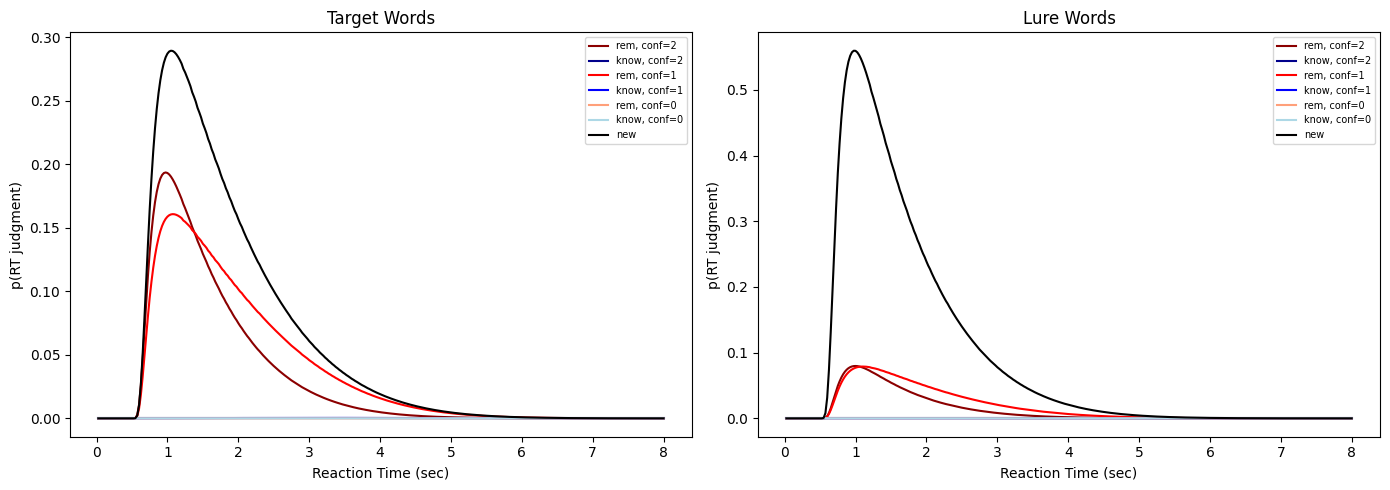

In [8]:
c_high     = [0.998, 0]
mu_r       = 0.05
d          = 0.35
tc_bound   = 0.1
r_bound_offset = 0.3
z0         = 0.02
deltaT     = 0.059
sigma_z0   = 0.002
t0         = 0.51
mu_r0      = -0.4

# targets
p_rem, p_know, p_new, t = predicted_proportions(
    c_high, mu_r, d, tc_bound, r_bound_offset, z0, deltaT, sigma_z0, t0)

# lures
p_rem_l, p_know_l, p_new_l, t = predicted_proportions(
    c_high, mu_r0, d, tc_bound, r_bound_offset, -z0, deltaT, sigma_z0, t0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ['conf=2', 'conf=1', 'conf=0']
colors_rem  = ['darkred', 'red', 'lightsalmon']
colors_know = ['darkblue', 'blue', 'lightblue']

for i in range(3):
    axes[0].plot(t, p_rem[i]  / DELTA_T, color=colors_rem[i],  label=f'rem, {confidence_labels[i]}')
    axes[0].plot(t, p_know[i] / DELTA_T, color=colors_know[i], label=f'know, {confidence_labels[i]}')
axes[0].plot(t, p_new / DELTA_T, color='black', label='new')
axes[0].set_title('Target Words')
axes[0].set_xlabel('Reaction Time (sec)')
axes[0].set_ylabel('p(RT judgment)')
axes[0].legend(fontsize=7)

for i in range(3):
    axes[1].plot(t, p_rem_l[i]  / DELTA_T, color=colors_rem[i],  label=f'rem, {confidence_labels[i]}')
    axes[1].plot(t, p_know_l[i] / DELTA_T, color=colors_know[i], label=f'know, {confidence_labels[i]}')
axes[1].plot(t, p_new_l / DELTA_T, color='black', label='new')
axes[1].set_title('Lure Words')
axes[1].set_xlabel('Reaction Time (sec)')
axes[1].set_ylabel('p(RT judgment)')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()